# 2.5 Kernel Density Estimation

In this notebook we use Kernel Density Estimation to identify trip demand hotspots.

### Data Requirements:

This notebook requires the following files: 

1. `01_06_trips_weather_merged.parquet` — local path: `data/merged/01_06_trips_weather_merged.parquet` — Sciebo path: `data_parquet/merged/01_06_trips_weather_merged.parquet`

2. `Boundaries_Community_Areas_20260608.geojson` — local path: `data/geometry/Boundaries_Community_Areas_20260608.geojson` — Sciebo path: `data_parquet/geometry/Boundaries_Community_Areas_20260608.geojson`

Sample data is provided in the appropriate locations for testing purposes only. It will not produce meaningful results.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/hendrik/Coding/Master/AAA/AAA_TA_2026


In [3]:
if Path("data/merged/01_06_trips_weather_merged.parquet").exists():
    df = pd.read_parquet("data/merged/01_06_trips_weather_merged.parquet")
else:
    df = pd.read_parquet("data/samples/SAMPLE_01_06_trips_weather_merged.parquet")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5369356 entries, 0 to 5369355
Data columns (total 39 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   trip_id                     str           
 1   taxi_id                     str           
 2   trip_start_timestamp        datetime64[ns]
 3   trip_end_timestamp          datetime64[ns]
 4   trip_seconds                float64       
 5   trip_miles                  float64       
 6   pickup_community_area       int64         
 7   dropoff_community_area      int64         
 8   fare                        float64       
 9   tips                        float64       
 10  tolls                       float64       
 11  extras                      float64       
 12  trip_total                  float64       
 13  payment_type                str           
 14  company                     str           
 15  pickup_centroid_latitude    float64       
 16  pickup_centroid_longitude   f

In [5]:
df["start_hour"] = df["trip_start_timestamp"].dt.hour

In [6]:

areas = gpd.read_file("data/geometry/Boundaries_Community_Areas_20260608.geojson").to_crs(3857)

areas

,:id,:version,:created_at,:updated_at,area_numbe,community,area_num_1,shape_area,shape_len,geometry
0,row-m77e_pkv8.vjvf,rv-3hjp_vkhx~fqfx,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,1,ROGERS PARK,1,51259902.4506,34052.3975757,"MULTIPOLYGON (((-9757660.529 5160704.746, -975..."
1,row-u375_347e-y6q8,rv-tgcx_t7fr-nkkg,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,2,WEST RIDGE,2,98429094.8621,43020.6894583,"MULTIPOLYGON (((-9761010.933 5163898.616, -976..."
2,row-kgqf-m29p-99kg,rv-bag4-8zri.nvhu,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,3,UPTOWN,3,65095642.7289,46972.7945549,"MULTIPOLYGON (((-9756154.198 5154211.526, -975..."
3,row-2dpv_pk9x-zybp,rv-82s2~rb54~emuc,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,4,LINCOLN SQUARE,4,71352328.2399,36624.6030848,"MULTIPOLYGON (((-9759870.406 5157400.522, -975..."
4,row-37zy.7r75.56p7,rv-hrse.ahu7-rz4d,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,5,NORTH CENTER,5,57054167.85,31391.6697542,"MULTIPOLYGON (((-9759754.254 5150850.097, -975..."
...,...,...,...,...,...,...,...,...,...,...
72,row-3uma_gs6v_expc,rv-cj4p_x3rj.brzz,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,73,WASHINGTON HEIGHTS,73,79635752.8769,42222.598163,"MULTIPOLYGON (((-9755342.627 5120449.037, -975..."
73,row-rn7j_sh22-jf8y,rv-a49v.s4vy~pudv,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,74,MOUNT GREENWOOD,74,75584290.0209,48665.1305392,"MULTIPOLYGON (((-9762325.229 5117211.619, -976..."
74,row-fiv3~fa4r~zk9e,rv-vip3.c98b.9m2d,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,75,MORGAN PARK,75,91877340.6988,46396.419362,"MULTIPOLYGON (((-9756279.738 5113922.382, -975..."
75,row-wewr.7jx4_gctv,rv-awj9_vhn6~tvpk,2025-04-22 23:06:36.944000+00:00,2025-04-22 23:06:36.944000+00:00,76,OHARE,76,371835607.687,173625.98466,"MULTIPOLYGON (((-9777923.456 5158941.865, -977..."


In [7]:
# calculate demand per centroid (census tract if available, else community area).
# use centroids since the KDE computes on a grid; calculating KDE for > 5 million rows would be too demanding.

frames = []
area_rows = df

area_demand = (
    area_rows.groupby("pickup_community_area")
      .size()
      .reset_index(name="trip_count")
)
area_centroids = (
    area_rows.groupby("pickup_community_area")[["pickup_centroid_latitude", "pickup_centroid_longitude"]]
      .first()
      .reset_index()
)
frames.append(area_demand.merge(area_centroids, on="pickup_community_area"))

# combine all demand at centroids
demand = pd.concat(frames, ignore_index=True)

## KDE Visualization

In [8]:
from scipy.stats import gaussian_kde

# implement KDE using weighted community area coordinates
xy = demand[["pickup_centroid_longitude", "pickup_centroid_latitude"]].values.T
weights = demand["trip_count"].values / demand["trip_count"].sum()

kde = gaussian_kde(xy, bw_method=0.1, weights=weights)

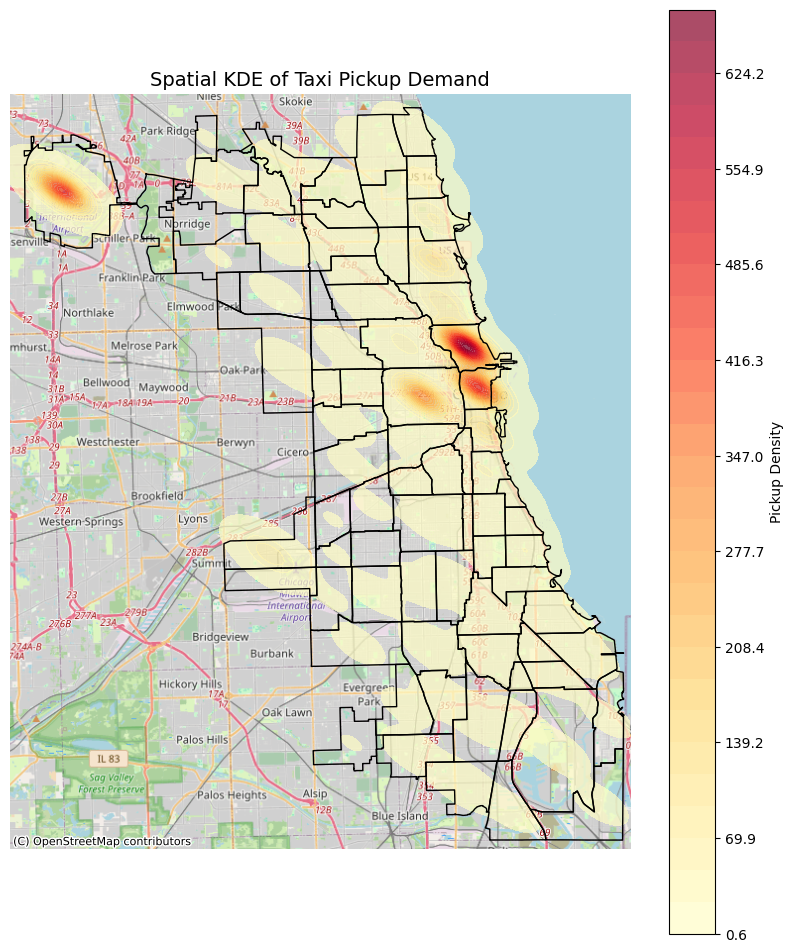

In [9]:
from shapely.geometry import Point
import contextily as cx

# evaluate KDE using an even grid over chicago
lon_min, lon_max = -87.95, -87.52
lat_min, lat_max = 41.64, 42.03

lon_grid = np.linspace(lon_min, lon_max, 300)
lat_grid = np.linspace(lat_min, lat_max, 300)
xx, yy = np.meshgrid(lon_grid, lat_grid)
zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

# convert the grid to mercator
gdf_grid = gpd.GeoDataFrame(
    geometry=[Point(lon, lat) for lon, lat in zip(xx.ravel(), yy.ravel())],
    crs="EPSG:4326"
).to_crs(epsg=3857)

xs = gdf_grid.geometry.x.values.reshape(xx.shape)
ys = gdf_grid.geometry.y.values.reshape(xx.shape)

# plot the kde distribution on the chicago map, including the community area shapes
fig, ax = plt.subplots(figsize=(10, 12))

# Highlight only the highest-density regions (top 30% of zz values)
levels = np.linspace(np.percentile(zz, 70), zz.max(), 30)

contour = ax.contourf(xs, ys, zz, levels=levels, cmap="YlOrRd", alpha=0.7)

plt.colorbar(contour, ax=ax, label= "Pickup Density")

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
areas.plot(ax = ax, facecolor="none", edgecolor="k")
ax.set_title("Spatial KDE of Taxi Pickup Demand", fontsize=14)
ax.set_axis_off()
plt.show()

Since the coordinates for each trip are the centroid coordinates of the corresponding community, instead of being exact coordinates, this visualization does not offer many new insights compared to the choropleth maps.

## Hotspots for different times of day

In [10]:
# create bins for different times of day
bins = {
    "Night (0–6)":         (0, 6),
    "Morning (6–12)":      (6, 12),
    "Afternoon (12–18)":   (12, 18),
    "Evening (18–24)":     (18, 24),
}

In [11]:
# compute demand and kde per time of day - bin
bin_demands = {}
bin_kdes = {}
for label, (h_start, h_end) in bins.items():
    subset = df[(df["start_hour"] >= h_start) & (df["start_hour"] < h_end)]

    frames = []
    area_rows = subset

    area_demand = (
        area_rows.groupby("pickup_community_area")
        .size()
        .reset_index(name="trip_count")
    )
    area_centroids = (
        area_rows.groupby("pickup_community_area")[["pickup_centroid_latitude", "pickup_centroid_longitude"]]
        .first()
        .reset_index()
    )
    frames.append(area_demand.merge(area_centroids, on="pickup_community_area"))

    # combine demand of census tracts and community areas for this time bin
    demand = pd.concat(frames, ignore_index=True)
    bin_demands[label] = demand

    xy = demand[["pickup_centroid_longitude", "pickup_centroid_latitude"]].values.T
    weights = demand["trip_count"].values / demand["trip_count"].sum()

    bin_kdes[label] = gaussian_kde(xy, bw_method=0.1, weights=weights)

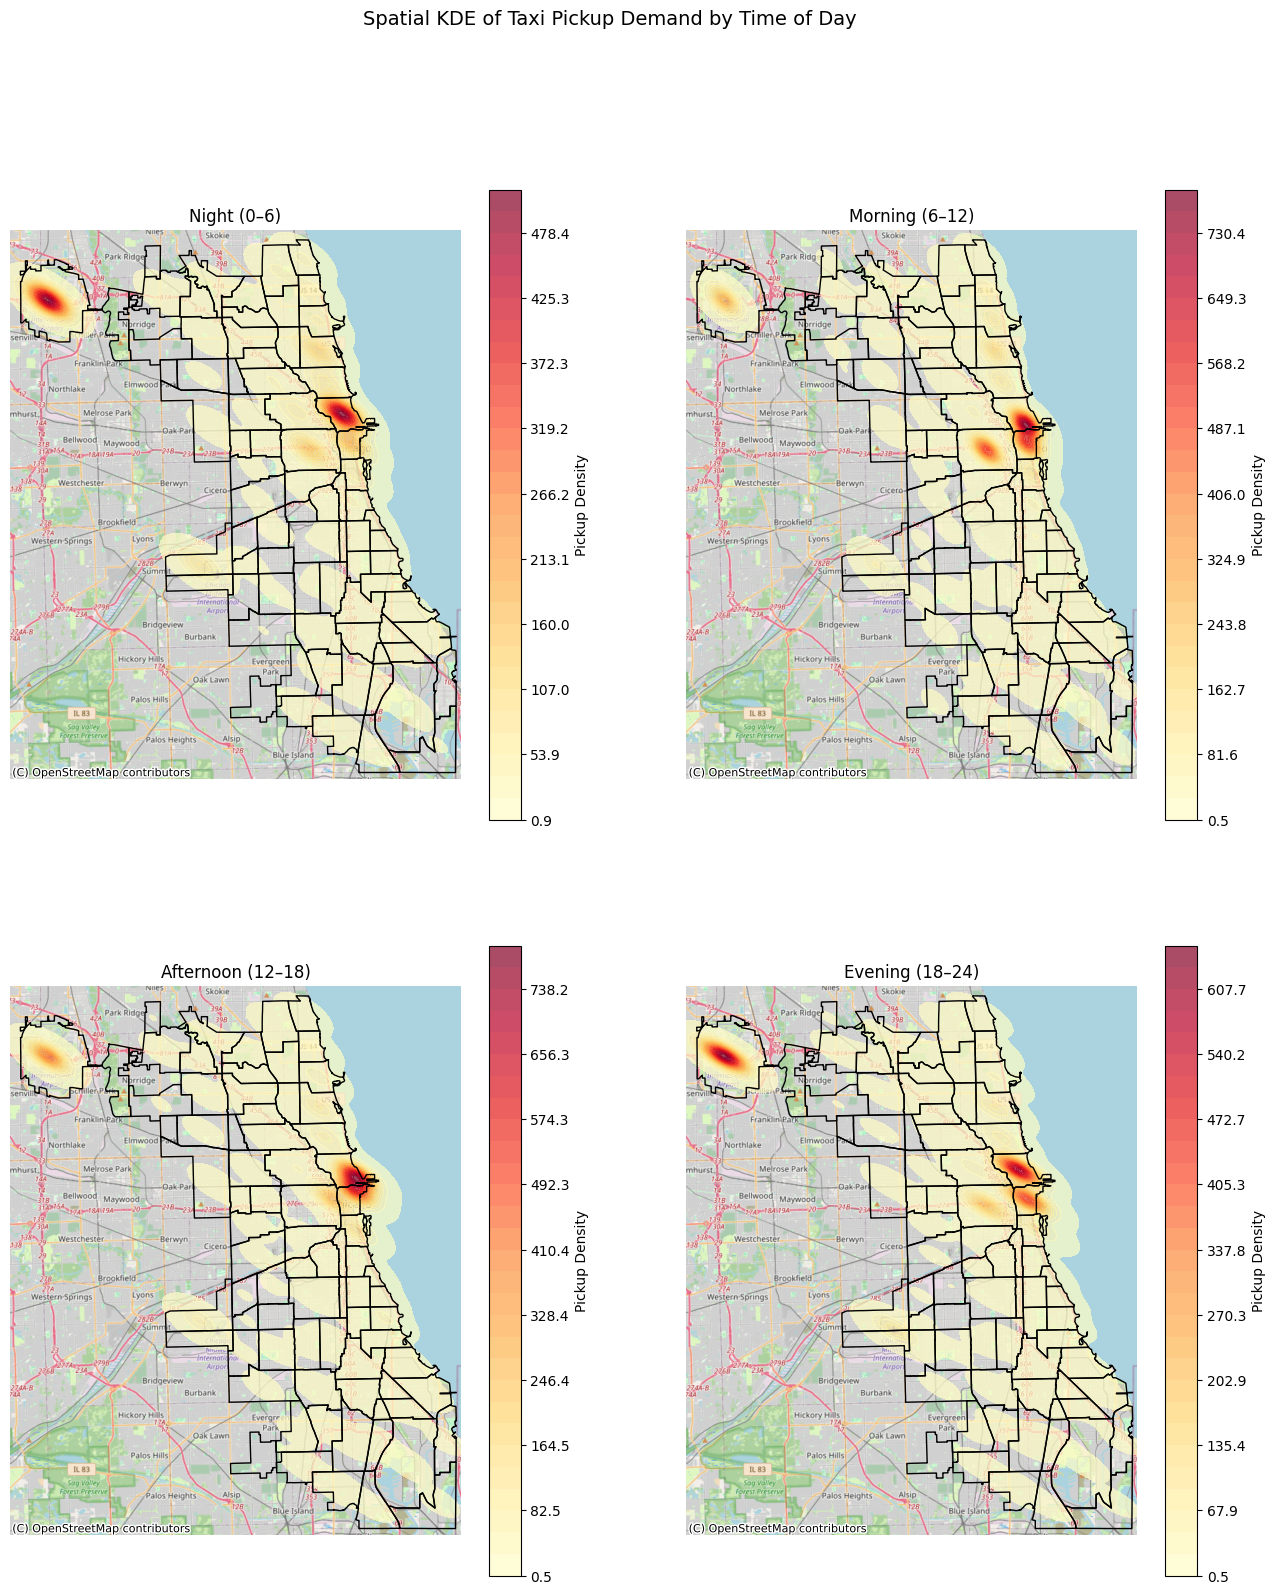

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 18))

# plot the KDE visualisation per time bin, including community area shapes
for ax, label in zip(axes.flat, bins.keys()):

    # compute the zz value per bin
    zz = bin_kdes[label](np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    # Highlight only the highest-density regions (top 30% of zz values)
    levels = np.linspace(np.percentile(zz, 70), zz.max(), 30)

    contour = ax.contourf(xs, ys, zz, levels=levels, cmap="YlOrRd", alpha=0.7)

    plt.colorbar(contour, ax=ax, label= "Pickup Density")

    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
    areas.plot(ax = ax, facecolor="none", edgecolor="k")
    ax.set_axis_off()
    ax.set_title(label)
    
plt.suptitle("Spatial KDE of Taxi Pickup Demand by Time of Day", fontsize=14)

plt.show()

# Finding Hotspots: Distributing Trips Within Their Areas

Instead of placing all trips at their area's center point, we scatter them randomly within the actual boundary—using census tracts when available for more precision, or community areas otherwise. This removes the artificial clustering at the center and improves hotspot analysis.

In [13]:
# source polygons in a metric CRS (EPSG:3857). Community areas are always available;
# the 2010 census tracts (whose GEOID10 matches the trip `pickup_census_tract`) are
# loaded only if that finer geometry is present.
community = areas[["area_numbe", "community", "geometry"]].copy()
community["area_numbe"] = community["area_numbe"].astype(int)

tracts = None
_tract_path = Path("data/geometry/tl_2010_17031_tract10")
if _tract_path.exists():
    tracts = (
        gpd.read_file(_tract_path)
           .to_crs(3857)[["GEOID10", "geometry"]]
           .rename(columns={"GEOID10": "geo_id"})
    )

In [14]:
# demand per source polygon, using the finest spatial unit the dataset provides:
# a census tract where the trip has one, otherwise the community area.
has_tract = (
    tracts is not None
    and "pickup_census_tract" in df.columns
    and df["pickup_census_tract"].notna().any()
)

frames = []
if has_tract:
    tract_mask = df["pickup_census_tract"].notna()
    tract_demand = (
        df[tract_mask].groupby("pickup_census_tract").size()
          .reset_index(name="trip_count")
          .rename(columns={"pickup_census_tract": "geo_id"})
    )
    tract_demand["geo_id"] = tract_demand["geo_id"].astype(str)
    frames.append(tract_demand.merge(tracts, on="geo_id", how="inner")[["trip_count", "geometry"]])
    area_rows = df[~tract_mask]                 # only trips without a tract fall back to the area
else:
    area_rows = df                              # dataset has no census tracts -> use community areas

area_demand = (
    area_rows.groupby("pickup_community_area").size()
      .reset_index(name="trip_count")
      .rename(columns={"pickup_community_area": "area_numbe"})
)
frames.append(area_demand.merge(community[["area_numbe", "geometry"]], on="area_numbe", how="inner")[["trip_count", "geometry"]])

# one row per source polygon carrying its demand
polys = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), crs=3857)
print(f"Spatial unit: {'census tracts + community areas' if has_tract else 'community areas only'} "
      f"({len(polys):,} source polygons)")

# spread a fixed budget of points across the polygons, proportional to demand,
# then place each polygon's share uniformly at random inside it
N_POINTS = 20_000
rng = np.random.default_rng(42)
polys["n_pts"] = np.floor(polys["trip_count"] / polys["trip_count"].sum() * N_POINTS).astype(int)
polys = polys[polys["n_pts"] > 0].copy()

coords = (
    polys.geometry.sample_points(size=polys["n_pts"].to_numpy(), rng=rng)
         .get_coordinates()[["x", "y"]].to_numpy()
)
print(f"{len(coords):,} pickup points scattered across {len(polys):,} areas (EPSG:3857)")

Spatial unit: community areas only (77 source polygons)
19,960 pickup points scattered across 77 areas (EPSG:3857)


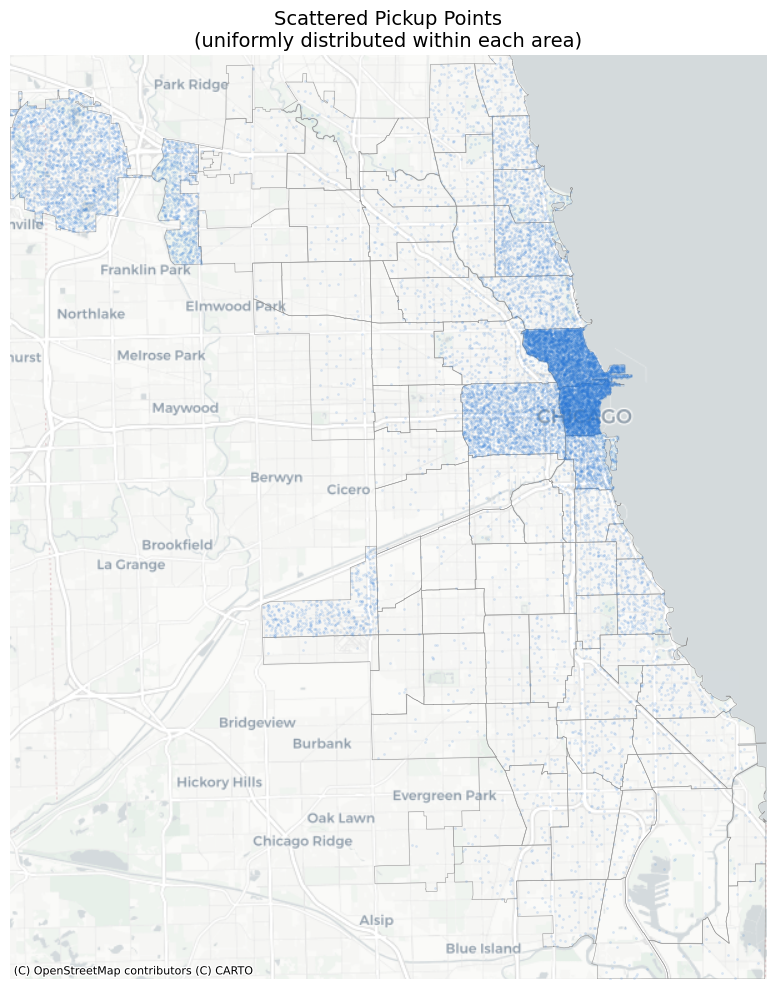

In [15]:
import contextily as cx

# the raw scattered pickup points, before any smoothing. A low opacity lets overlapping
# points accumulate, so dense areas read solid and sparse areas fade out.
minx, miny, maxx, maxy = community.total_bounds

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
community.plot(ax=ax, facecolor="none", edgecolor="0.6", linewidth=0.4)

ax.scatter(coords[:, 0], coords[:, 1], s=4, color="#2a78d6", alpha=0.15, linewidths=0)

ax.set_title(f"Scattered Pickup Points\n(uniformly distributed within each area)", fontsize=14)
ax.set_axis_off()
plt.show()

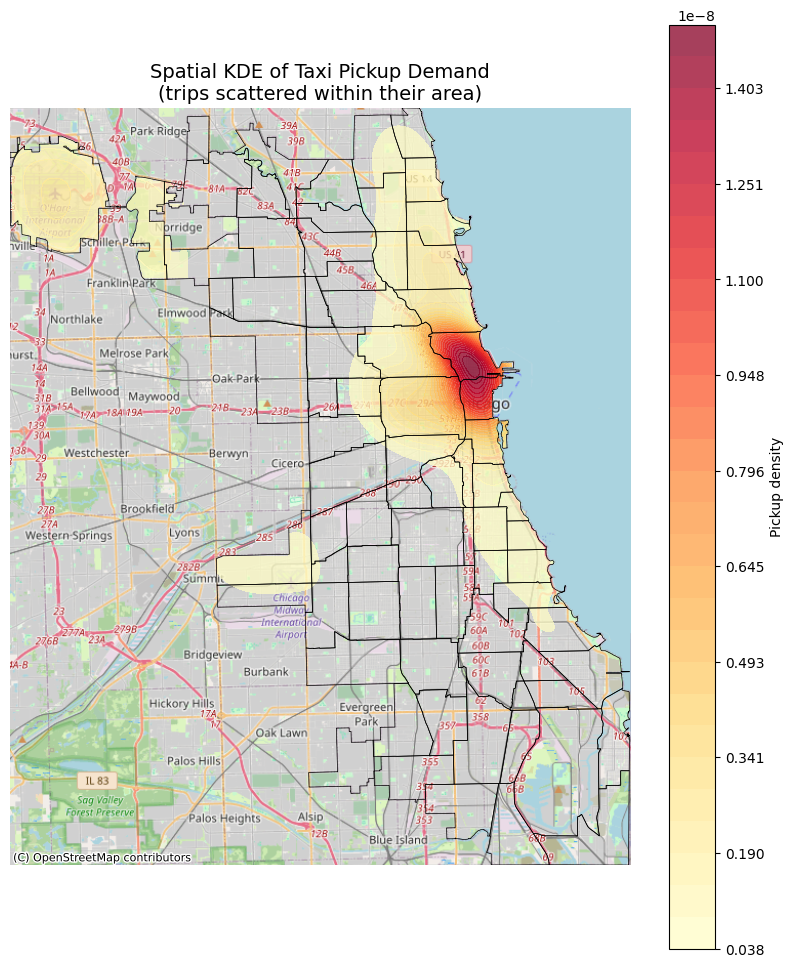

In [16]:
from scipy.stats import gaussian_kde
from shapely import points as shp_points, contains
import contextily as cx

# KDE over the scattered points, evaluated on a grid covering the city
kde = gaussian_kde(coords.T, bw_method=0.15)

minx, miny, maxx, maxy = community.total_bounds
gx = np.linspace(minx, maxx, 300)
gy = np.linspace(miny, maxy, 300)
GX, GY = np.meshgrid(gx, gy)
Z = kde(np.vstack([GX.ravel(), GY.ravel()])).reshape(GX.shape)

# clip to the actual city footprint so the surface doesn't bleed into the lake / suburbs
city = community.geometry.union_all()
inside = contains(city, shp_points(GX.ravel(), GY.ravel())).reshape(GX.shape)
Z = np.where(inside, Z, np.nan)

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

# highlight the densest regions (top 30% of the surface)
levels = np.linspace(np.nanpercentile(Z, 70), np.nanmax(Z), 30)
contour = ax.contourf(GX, GY, Z, levels=levels, cmap="YlOrRd", alpha=0.75)
plt.colorbar(contour, ax=ax, label="Pickup density")
community.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
ax.set_title("Spatial KDE of Taxi Pickup Demand\n(trips scattered within their area)", fontsize=14)
ax.set_axis_off()
plt.show()

## Hotspots for different times of day (scattered within areas)

We repeat the time-of-day breakdown from the first part, but now with the improved approach: instead of collapsing each trip onto its area's centroid, we scatter each area's trips uniformly at random inside its polygon before smoothing. This removes the centroid artifact and reveals how the genuine demand surface shifts between night, morning, afternoon and evening.

In [17]:
# scatter-within-polygon KDE per time-of-day bin: the same demand -> scatter -> KDE
# pipeline as the city-wide plot above, repeated on each bin's subset of trips.
N_POINTS = 20_000
bin_scatter_kdes = {}

for label, (h_start, h_end) in bins.items():
    subset = df[(df["start_hour"] >= h_start) & (df["start_hour"] < h_end)]

    # demand per source polygon for this bin (census tract where available, else community area)
    frames = []
    if has_tract:
        tract_mask = subset["pickup_census_tract"].notna()
        tract_demand = (
            subset[tract_mask].groupby("pickup_census_tract").size()
              .reset_index(name="trip_count")
              .rename(columns={"pickup_census_tract": "geo_id"})
        )
        tract_demand["geo_id"] = tract_demand["geo_id"].astype(str)
        frames.append(tract_demand.merge(tracts, on="geo_id", how="inner")[["trip_count", "geometry"]])
        area_rows = subset[~tract_mask]
    else:
        area_rows = subset

    area_demand = (
        area_rows.groupby("pickup_community_area").size()
          .reset_index(name="trip_count")
          .rename(columns={"pickup_community_area": "area_numbe"})
    )
    frames.append(area_demand.merge(community[["area_numbe", "geometry"]], on="area_numbe", how="inner")[["trip_count", "geometry"]])

    polys_bin = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), crs=3857)

    # spread a fixed point budget proportional to demand, placed uniformly within each polygon
    rng = np.random.default_rng(42)
    polys_bin["n_pts"] = np.floor(polys_bin["trip_count"] / polys_bin["trip_count"].sum() * N_POINTS).astype(int)
    polys_bin = polys_bin[polys_bin["n_pts"] > 0].copy()

    coords_bin = (
        polys_bin.geometry.sample_points(size=polys_bin["n_pts"].to_numpy(), rng=rng)
             .get_coordinates()[["x", "y"]].to_numpy()
    )

    bin_scatter_kdes[label] = gaussian_kde(coords_bin.T, bw_method=0.15)

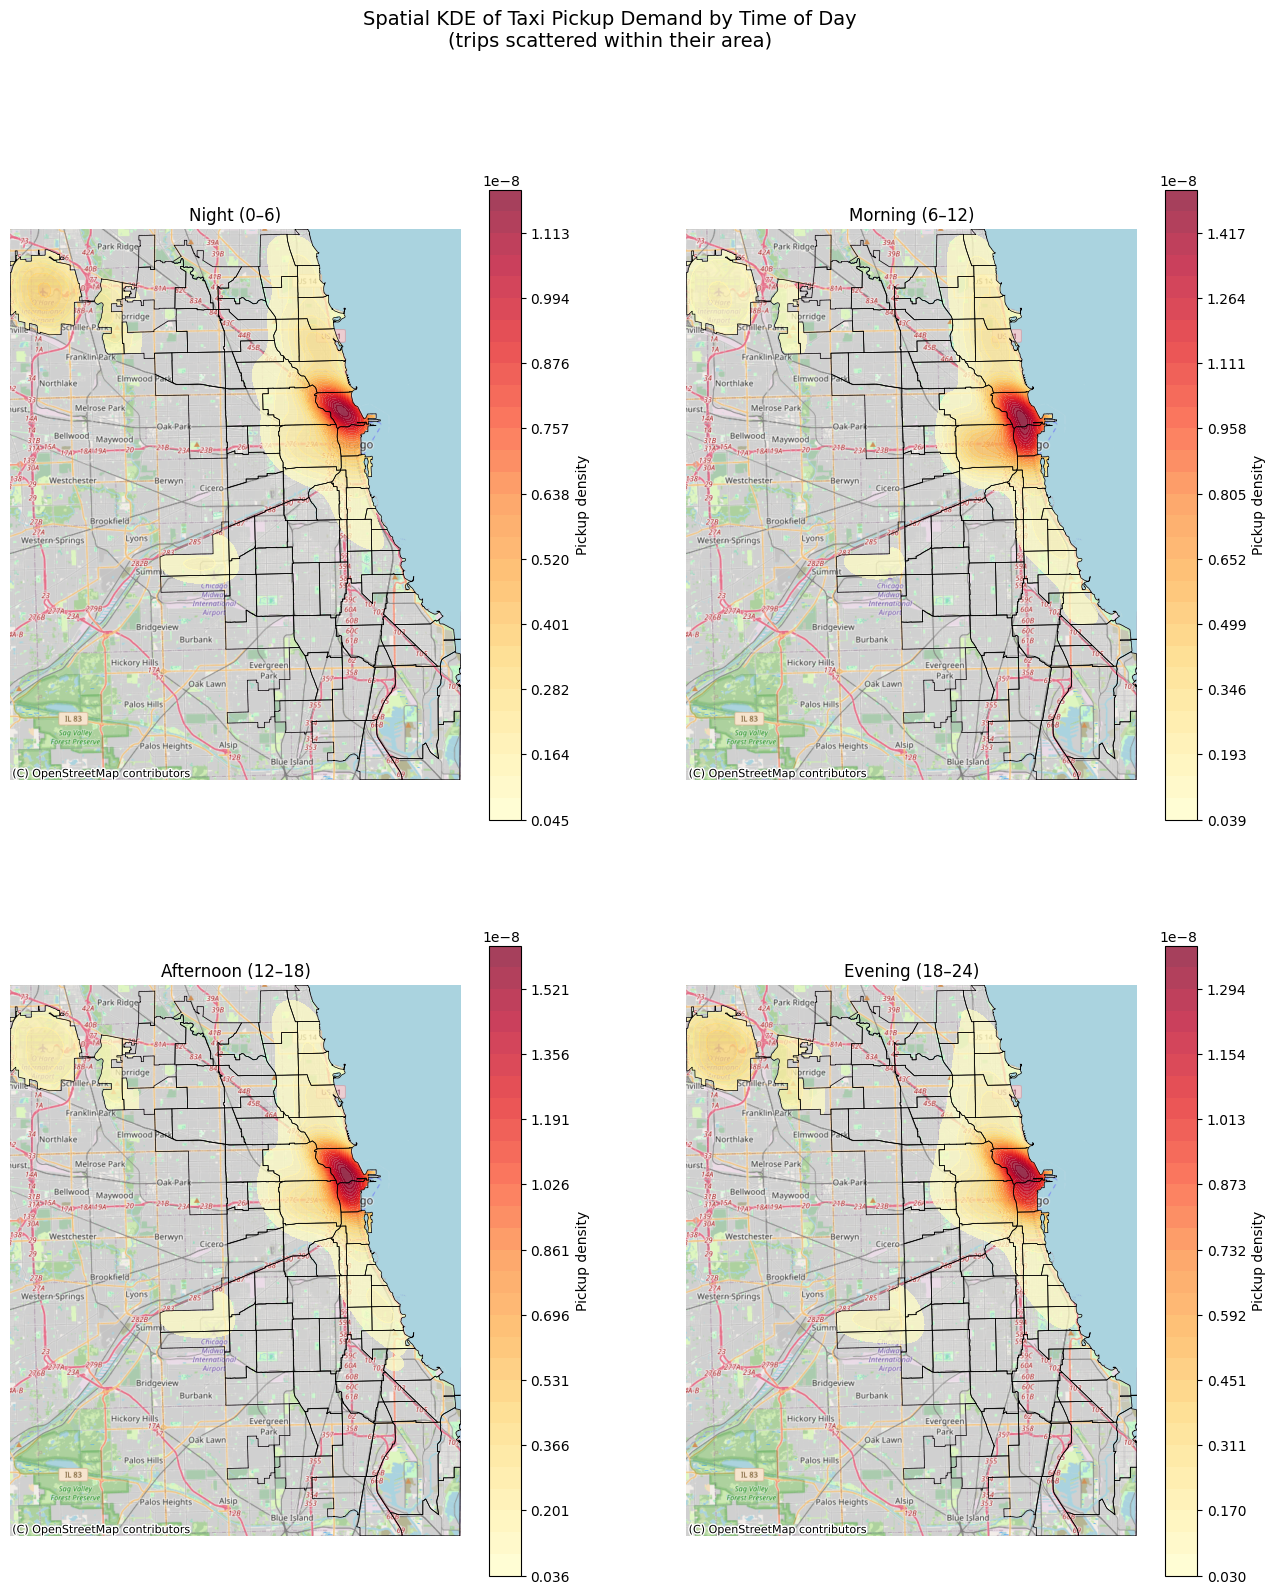

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 18))

# plot the scatter-based KDE surface per time bin, clipped to the city footprint
for ax, label in zip(axes.flat, bins.keys()):

    # evaluate this bin's KDE on the shared grid and mask to the city footprint
    Z = bin_scatter_kdes[label](np.vstack([GX.ravel(), GY.ravel()])).reshape(GX.shape)
    Z = np.where(inside, Z, np.nan)

    ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

    # highlight the densest regions (top 30% of the surface)
    levels = np.linspace(np.nanpercentile(Z, 70), np.nanmax(Z), 30)
    contour = ax.contourf(GX, GY, Z, levels=levels, cmap="YlOrRd", alpha=0.75)
    plt.colorbar(contour, ax=ax, label="Pickup density")
    community.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
    ax.set_axis_off()
    ax.set_title(label)

plt.suptitle("Spatial KDE of Taxi Pickup Demand by Time of Day\n(trips scattered within their area)", fontsize=14)
plt.show()